In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('final_crop_yield_dataset.csv')

In [3]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Total_Rainfall_Jan_Aug,tavg,tmin,tmax,prcp
0,andaman and nicobar islands,nicobars,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,NaN,NaN,NaN,NaN,NaN
1,andaman and nicobar islands,nicobars,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000,NaN,NaN,NaN,NaN,NaN
2,andaman and nicobar islands,nicobars,2000,Kharif,Rice,102.0,321.0,3.147059,NaN,NaN,NaN,NaN,NaN
3,andaman and nicobar islands,nicobars,2000,Whole Year,Banana,176.0,641.0,3.642045,NaN,NaN,NaN,NaN,NaN
4,andaman and nicobar islands,nicobars,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242361 entries, 0 to 242360
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   State_Name              242361 non-null  object 
 1   District_Name           242361 non-null  object 
 2   Crop_Year               242361 non-null  int64  
 3   Season                  242361 non-null  object 
 4   Crop                    242361 non-null  object 
 5   Area                    242361 non-null  float64
 6   Production              242361 non-null  float64
 7   Yield                   242361 non-null  float64
 8   Total_Rainfall_Jan_Aug  185142 non-null  float64
 9   tavg                    228028 non-null  float64
 10  tmin                    228028 non-null  float64
 11  tmax                    228028 non-null  float64
 12  prcp                    228028 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 24.0+ MB


In [5]:
df = df.drop(columns=['Yield'])

In [6]:
df.describe()

,Crop_Year,Area,Production,Total_Rainfall_Jan_Aug,tavg,tmin,tmax,prcp
count,242361.000000,2.423610e+05,2.423610e+05,185142.000000,228028.000000,228028.000000,228028.000000,228028.000000
mean,2005.625773,1.216741e+04,5.825034e+05,918.453573,25.788282,20.728851,31.547890,115.283268
std,4.958285,5.085744e+04,1.706581e+07,589.438004,1.687986,1.968862,1.461021,34.505782
min,1997.000000,1.000000e-01,0.000000e+00,152.800000,16.058929,11.203571,22.000000,55.097106
25%,2002.000000,8.700000e+01,8.800000e+01,561.800000,25.139198,19.690257,31.105556,87.612037
50%,2006.000000,6.030000e+02,7.290000e+02,766.300000,25.672222,20.355689,31.327778,115.841104
75%,2010.000000,4.545000e+03,7.023000e+03,1029.900000,27.084804,21.973481,32.470229,132.396985
max,2015.000000,8.580100e+06,1.250800e+09,5975.700000,28.367365,24.512315,33.376408,235.350754


In [17]:
crop_count = df['Crop'].value_counts().sort_values()
drop_crop = crop_count[crop_count<9].index
drop_crop

Index(['Other Dry Fruit', 'Peach', 'Apple', 'Plums', 'Litchi', 'Pear',
       'Coffee', 'Turnip'],
      dtype='object', name='Crop')

In [18]:
df[df['Crop'].isin(drop_crop)]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Total_Rainfall_Jan_Aug,tavg,tmin,tmax,prcp
72704,jammu and kashmir,kargil,2002,Whole Year,Turnip,161.0,64.0,159.1,18.445139,12.459028,24.721528,78.938194
72712,jammu and kashmir,kargil,2003,Whole Year,Turnip,311.0,123.0,159.1,18.445139,12.459028,24.721528,78.938194
73024,jammu and kashmir,leh ladakh,2002,Whole Year,Turnip,20.0,16.0,NaN,18.445139,12.459028,24.721528,78.938194
73037,jammu and kashmir,leh ladakh,2003,Whole Year,Turnip,38.0,30.0,NaN,18.445139,12.459028,24.721528,78.938194
73501,jammu and kashmir,srinagar,2002,Whole Year,Turnip,105.0,65.0,538.2,18.445139,12.459028,24.721528,78.938194
73521,jammu and kashmir,srinagar,2003,Whole Year,Turnip,105.0,65.0,538.2,18.445139,12.459028,24.721528,78.938194
96686,kerala,idukki,2001,Whole Year,Coffee,12635.0,9130.0,2429.9,28.239524,24.512315,32.275862,235.350754
96711,kerala,idukki,2002,Whole Year,Coffee,11490.0,8475.0,2429.9,28.239524,24.512315,32.275862,235.350754
98686,kerala,palakkad,2001,Whole Year,Coffee,4650.0,3450.0,1682.8,28.239524,24.512315,32.275862,235.350754
98712,kerala,palakkad,2002,Whole Year,Coffee,4650.0,2150.0,1682.8,28.239524,24.512315,32.275862,235.350754


In [19]:
crop_count.describe()

count      124.000000
mean      1954.524194
std       3033.226050
min          1.000000
25%         39.000000
50%        299.000000
75%       3192.000000
max      15082.000000
Name: count, dtype: float64

In [20]:
df[df['Crop'].isin(drop_crop)].value_counts().sum()

np.int64(28)

In [21]:
df['Production'].describe()

count    2.423610e+05
mean     5.825034e+05
std      1.706581e+07
min      0.000000e+00
25%      8.800000e+01
50%      7.290000e+02
75%      7.023000e+03
max      1.250800e+09
Name: Production, dtype: float64

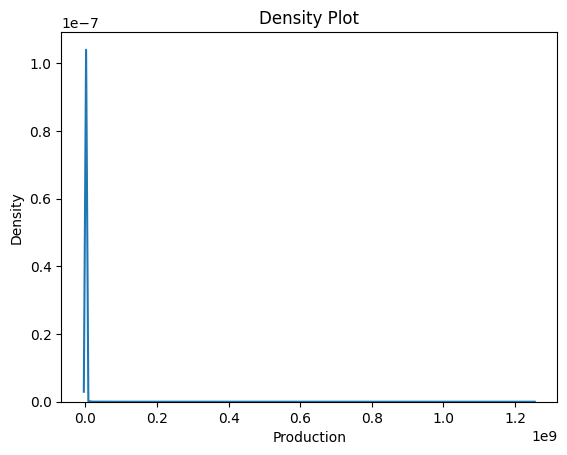

In [22]:
sns.kdeplot(df['Production'])
plt.xlabel('Production')
plt.title('Density Plot')
plt.show()

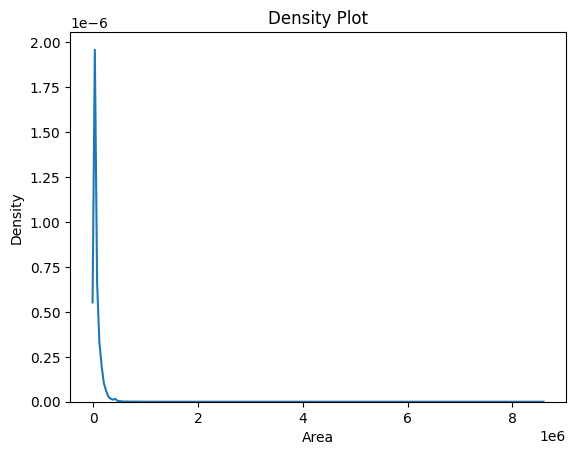

In [23]:
sns.kdeplot(df['Area'])
plt.xlabel('Area')
plt.title('Density Plot')
plt.show()

In [24]:
df['Production'].sample(10)

117174      4827.0
22595        568.0
84036        138.0
83134       2461.0
30590         75.0
143716       200.0
123577      5500.0
232942      8685.0
126949     20900.0
93581     269202.0
Name: Production, dtype: float64

In [25]:
df_new = df

In [26]:
df[df['Production']<10].shape[0]

23462

In [28]:
df_new = df_new[df_new['Production'] >= 10]

In [29]:
df_new.shape[0]

218899

In [31]:
X = df_new.drop(columns=['Production'])
y = df_new['Production']

In [30]:
imp = ColumnTransformer(transformers=[
    ('SimpleImpute1',SimpleImputer(strategy='mean'),['Total_Rainfall_Jan_Aug']),
    ('SimpleImpute2',SimpleImputer(strategy='median'),['tavg','tmin','tmax','prcp'])
],remainder='passthrough')

In [51]:
num_cols_mean = ['Total_Rainfall_Jan_Aug']
num_cols_median = ['tavg', 'tmin', 'tmax', 'prcp']
num_cols_none = ['Area', 'Crop_Year']

cat_cols_ohe = ['Season']
cat_cols_te = ['State_Name', 'District_Name', 'Crop']

num_mean_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
num_median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
num_none_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [52]:
preprocessor = ColumnTransformer(transformers=[
    ('num_mean', num_mean_pipeline, num_cols_mean),
    ('num_median', num_median_pipeline, num_cols_median),
    ('num_none', num_none_pipeline, num_cols_none),
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_ohe),
    ('cat_te', TargetEncoder(target_type='continuous'), cat_cols_te)
])

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (175119, 16)
X_test_processed shape: (43780, 16)


In [55]:
ridge = Ridge()
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(ridge, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_processed, y_train)

best_ridge = grid_search.best_estimator_
y_pred_lr = best_ridge.predict(X_test_processed)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Best Ridge Alpha: {grid_search.best_params_['alpha']}")
print(f"Ridge Regression R2 Score: {r2_lr:.4f}")
print(f"Ridge Regression RMSE: {rmse_lr:.4f}")


Best Ridge Alpha: 100.0
Ridge Regression R2 Score: 0.1763
Ridge Regression RMSE: 15050717.8833


In [56]:
def build_ann(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
                  loss='mse', metrics=['mae'])
    return model

In [70]:
ann_model = build_ann(X_train_processed.shape[1])

In [71]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = ann_model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 318721604190208.0000 - mae: 648354.1875 - val_loss: 393550437023744.0000 - val_mae: 723103.3125 - learning_rate: 0.0100
Epoch 2/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 313293201735680.0000 - mae: 913020.6250 - val_loss: 376388049698816.0000 - val_mae: 775153.4375 - learning_rate: 0.0100
Epoch 3/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 300418567503872.0000 - mae: 1363698.1250 - val_loss: 344675789570048.0000 - val_mae: 1044697.7500 - learning_rate: 0.0100
Epoch 4/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 283069114220544.0000 - mae: 1440038.2500 - val_loss: 303698211241984.0000 - val_mae: 666236.8125 - learning_rate: 0.0100
Epoch 5/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 257149942890496.0000 - mae: 1460395.2500 - val_loss: 255863583408128.0000 - val_mae: 670195.6250 - learning_rate: 0.0100
Epoch 6/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 231567322513408.0000 - mae: 1343950.

In [72]:
y_pred_ann = ann_model.predict(X_test_processed).flatten()

r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print(f"ANN R2 Score: {r2_ann:.4f}")
print(f"ANN RMSE: {rmse_ann:.4f}")

1369/1369 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step
ANN R2 Score: 0.7882
ANN RMSE: 7631387.3598


In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_regressor = RandomForestRegressor(n_jobs=-1,random_state=42)

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [None, 15, 25, 35, 50],
    'min_samples_leaf': randint(1, 10),
    'min_samples_split': randint(2, 15),
    'max_features': ['sqrt', 'log2', 1.0] # 1.0 means all features
}

random_search = RandomizedSearchCV(
    estimator=rf_regressor, 
    param_distributions=param_dist, 
    n_iter=20,
    cv=3,
    scoring='r2', 
    n_jobs=-1,
    verbose=2,          
    random_state=42
)

In [80]:
random_search.fit(X_train_processed, y_train)

best_rf_pipeline = random_search.best_estimator_
print("\n--- Best Parameters Found ---")
print(random_search.best_params_)

y_pred_rf = best_rf_pipeline.predict(X_test_processed)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Best Parameters Found ---
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 262}


In [81]:
print(f"\nRandom Forest R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")


Random Forest R2 Score: 0.8783
Random Forest RMSE: 5784774.4297


In [83]:
import xgboost as xgb
from scipy.stats import uniform
xgb_regressor = xgb.XGBRegressor(
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
param_dist_xgb = {
    'n_estimators': randint(100, 500),         # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),       # Step size shrinkage (usually 0.01 to 0.2 is best)
    'max_depth': randint(3, 10),               # Max depth of a tree (XGBoost prefers shallower trees than RF)
    'subsample': uniform(0.6, 0.4),            # Fraction of data to use for each tree (prevents overfitting)
    'colsample_bytree': uniform(0.6, 0.4),     # Fraction of features to use for each tree
    'min_child_weight': randint(1, 7)          # Minimum sum of instance weight needed in a child
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_regressor, 
    param_distributions=param_dist_xgb, 
    n_iter=20,
    cv=3, 
    scoring='r2', 
    n_jobs=-1,
    verbose=2, 
    random_state=42
)

In [84]:
random_search_xgb.fit(X_train_processed, y_train)
best_xgb_model = random_search_xgb.best_estimator_

print("\n--- Best XGBoost Parameters Found ---")
print(random_search_xgb.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Best XGBoost Parameters Found ---
{'colsample_bytree': np.float64(0.662397808134481), 'learning_rate': np.float64(0.021616722433639893), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 459, 'subsample': np.float64(0.8832290311184181)}


In [85]:
y_pred_xgb = best_xgb_model.predict(X_test_processed)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"\nXGBoost R2 Score: {r2_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")


XGBoost R2 Score: 0.9486
XGBoost RMSE: 3758728.6611


In [86]:
results_data = {
    'Model': ['Ridge Regression', 'Artificial Neural Network', 'Random Forest', 'XGBoost'],
    'R2 Score': [r2_lr,r2_ann,r2_score(y_test, y_pred_rf),r2_score(y_test, y_pred_xgb)],
    'RMSE': [rmse_lr,rmse_ann,np.sqrt(mean_squared_error(y_test, y_pred_rf)),np.sqrt(mean_squared_error(y_test, y_pred_xgb))]
}
results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

results_df

,Model,R2 Score,RMSE
0,XGBoost,0.948626,3.758729e+06
1,Random Forest,0.878317,5.784774e+06
2,Artificial Neural Network,0.788230,7.631387e+06
3,Ridge Regression,0.176293,1.505072e+07


In [87]:
final_project_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_xgb_model)
])

In [88]:
joblib.dump(final_project_pipeline, 'production_prediction_pipeline.pkl')

['production_prediction_pipeline.pkl']